<a href="https://colab.research.google.com/github/pablojbec/Analysis_TomTom/blob/main/Analysis_TomTom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introducción

El objeto de este análisis es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Para ello se trabajará con datos de TomTom Traffic Index y OECD Cities, los cuales se analizarán para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 1. Carga e inspección de datos

Antes de limpiar o combinar los datos, es necesario **familiarizarse con la estructura de los datasets**.

### 1.1 Carga de datos y vista rápida


In [ ]:
# importe de librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# carga de archivos
traffic = pd.read_csv('D:/Users/Windows 10/Documents/Analisis_datos/Movilidad_TomTom/datasets/tomtom_traffic.csv')
eco = pd.read_csv('D:/Users/Windows 10/Documents/Analisis_datos/Movilidad_TomTom/datasets/oecd_city_economy.csv')

In [ ]:
# mostrar las primeras 5 filas de traffic
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
# mostrar las primeras 5 filas de eco
eco.head(5)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## 🧩2. Inspección, limpieza y prepararación de datos

Antes de combinar los datasets, se inspecciona su estructura, tipos de datos, columnas y valores faltantes.

### 2.1 Inspección de la estructura y tipos de datos


In [ ]:
# Inspección de la estructura de traffic
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

En la estructura del dataset traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` son de tipo object
- Las columnas 'JamsDelay', 'TrafficIndexLive', 'JamsLengthInKms', 'JamsCount', 'TrafficIndexWeekAgo', 'TravelTimeLivePer10KmsMins', 'TravelTimeHistoricPer10KmsMins' y MinsDelay son de tipo float64

In [ ]:
# Inspección de la estructura de eco
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


En la estructura del dataset eco, se observa que:
- Las columnas 'City', 'GDP/capita', 'Unemployment %', 'PM2.5 (μg/m³)' y  'Population (M)'son de tipo object
- La columna 'Year' es de tipo int64

### 2.2 Renombre de columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

In [ ]:
# Creación de copia traffic
traffic_clean = traffic.copy()
# Estandarización de los nombres de las columnas de traffic
traffic_clean = traffic_clean.rename(columns={'City':'city','Country' : 'country','UpdateTimeUTC' : 'update_time_utc','UpdateTimeUTCWeekAgo':'update_time_utc_week_ago','JamsDelay':'jams_delay', 'TrafficIndexLive':'traffic_index_live', 'JamsLengthInKms':'jams_length_kms', 'JamsCount':'jams_count', 'MinsDelay':'mins_delay','TravelTimeLivePer10KmsMins':'travel_time_live_per_10kms_mins', 'TravelTimeHistoricPer10KmsMins':'travel_time_hist_per_10kms_mins'})

# verificación de cambios
traffic_clean.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'TrafficIndexWeekAgo', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins', 'travel_time_hist_per_10kms_mins',
       'mins_delay'],
      dtype='object')

In [ ]:
#Creación de copia eco
eco_clean = eco.copy()
# Estandarizarización de los nombres de las columnas de eco
eco_clean = eco_clean.rename(columns={'City':'city','Year':'year','Country':'country','City GDP/capita':'city_gdp_capita','Unemployment %':'unemployment_pct','PM2.5 (μg/m³)':'pm25', 'Population (M)':'population_m'})

# verificación de cambios
eco_clean.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')


### 2.3 Corrección de formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

In [ ]:
# Conversión de las columnas de traffic a tipo fecha con pd.to_datetime()
traffic_clean['update_time_utc'] = pd.to_datetime(traffic_clean['update_time_utc'], errors='coerce', utc=True)
traffic_clean['update_time_utc_week_ago'] = pd.to_datetime(traffic_clean['update_time_utc_week_ago'], errors='coerce', utc=True)

# verificación del cambio
traffic_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                           Non-Null Count    Dtype              
---  ------                           --------------    -----              
 0   country                          1004464 non-null  object             
 1   city                             1004464 non-null  object             
 2   update_time_utc                  1004464 non-null  datetime64[ns, UTC]
 3   jams_delay                       1004464 non-null  float64            
 4   traffic_index_live               1004464 non-null  float64            
 5   jams_length_kms                  1004464 non-null  float64            
 6   jams_count                       1004464 non-null  float64            
 7   TrafficIndexWeekAgo              1004464 non-null  float64            
 8   update_time_utc_week_ago         1004464 non-null  datetime64[ns, UTC]
 9   travel_time_live_per_10kms_mins  1004464 non-n

In [ ]:

# Limpieza de separadores y conversión de columnas numéricas en eco
eco_clean['city_gdp_capita'] = eco_clean['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco_clean['unemployment_pct'] = eco_clean['unemployment_pct'].astype(str).str.replace('%', '').str.replace('.', '').str.replace(',', '.').astype(float)
eco_clean['population_m'] = eco_clean['population_m'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)

eco_clean['pm25'] = pd.to_numeric(eco_clean['pm25'], errors='coerce')

# Calculo de la población total en unidades absolutas (Multiplica * 1000000)
eco_clean['population'] = eco_clean['population_m']*1000000

# verificación del cambio
eco_clean.info()
eco_clean.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              0 non-null      float64
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,62.0,NaN,15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,91.0,NaN,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,98.0,NaN,13.6,13600000.0



---

## 🧩3. Extracción de año y filtrado

Se extrae el año para filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extracción de columna año y para filtrado

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

In [ ]:
# Extracción del año en la columna de fechas
traffic_clean['year'] =traffic_clean['update_time_utc'].dt.year

# Verificación del cambio
traffic_clean.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,TrafficIndexWeekAgo,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtra los registros del año 2024
traffic_2024 = traffic_clean[\
    (traffic_clean['year']== 2024) &\
    (traffic_clean['country'].isin(['ARG', 'BRA', 'CHL', 'COL', 'MEX', 'PER', 'URY' ]))].copy()
eco_2024 =eco_clean[eco_clean['year']==2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,TrafficIndexWeekAgo,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,mins_delay,year
15967,ARG,buenos-aires,2024-12-31 23:46:30+00:00,138.3,11.0,44.6,43.0,26.0,2024-12-24 23:46:30+00:00,16.569802,16.818738,-0.248936,2024
15968,ARG,buenos-aires,2024-12-31 23:31:30+00:00,66.8,9.0,26.6,27.0,26.0,2024-12-24 23:46:30+00:00,16.142125,16.941469,-0.799344,2024
15969,ARG,buenos-aires,2024-12-31 22:46:30+00:00,33.5,5.0,8.6,14.0,11.0,2024-12-24 22:46:30+00:00,15.614398,17.302789,-1.688390,2024
15970,ARG,buenos-aires,2024-12-31 21:31:30+00:00,25.7,3.0,2.6,9.0,6.0,2024-12-24 21:31:30+00:00,15.369625,17.047480,-1.677855,2024
15971,ARG,buenos-aires,2024-12-31 20:46:30+00:00,34.6,2.0,3.8,12.0,5.0,2024-12-24 20:01:30+00:00,15.215201,16.627765,-1.412564,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,72.0,NaN,15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,85.0,NaN,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,92.0,NaN,13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,78.0,NaN,4.8,4800000.0
19,2024,salvador,Brazil,8899.0,124.0,NaN,3.9,3900000.0



---

## 🧩4. Analisis y resumen de datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, se calculan los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calculo de promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.


In [ ]:
# Calculo de los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = (
    traffic_2024
    .groupby(['city', 'country', 'year'])[
        ['jams_delay', 'traffic_index_live', 'jams_length_kms',
         'jams_count', 'mins_delay',
         'travel_time_live_per_10kms_mins',
         'travel_time_hist_per_10kms_mins']
    ]
    .mean()
    .reset_index()
)

# Resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736


In [ ]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
7,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
14,sao-paulo,BRA,2024,1729.189270,26.877932,238.419896,431.470460,1.129026,20.801836,19.672810
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557
6,lima,PER,2024,1052.292789,31.031277,110.314770,213.453519,1.506305,25.674261,24.167956
13,santiago,CHL,2024,629.865318,20.155352,93.489121,153.095300,0.627445,17.031310,16.403864
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349
11,rio-de-janeiro,BRA,2024,466.064706,25.162963,85.015120,123.891939,0.361302,17.137320,16.776018
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736
9,porto-alegre,BRA,2024,139.382830,17.687254,20.167849,39.813403,0.194195,16.166684,15.972490


La ciudad con el mayor tiempo promedio de tráfico en Latinoamerica es Ciudad de Mexico.


---

## 🧩5. Unión de datasets de movilidad y economía

Combinar datasets para analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unión de tráfico con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.


In [ ]:
# Selección de columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# creación de los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small =eco_2024[right_cols].copy()

# Unión datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city','year'], how='outer')

# Mostrar las primeras 5 filas
merged.head(5)

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,95.0,NaN,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,NaN,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,78.0,NaN,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,72.0,NaN,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,82.0,NaN,3700000.0



---

## 🧩6. Visualización y análisis de relaciones

Ahora que ya se tiene un dataset limpio y unificado, se deben **visualizar patrones**.
Los gráficos ayudan a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualización de relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

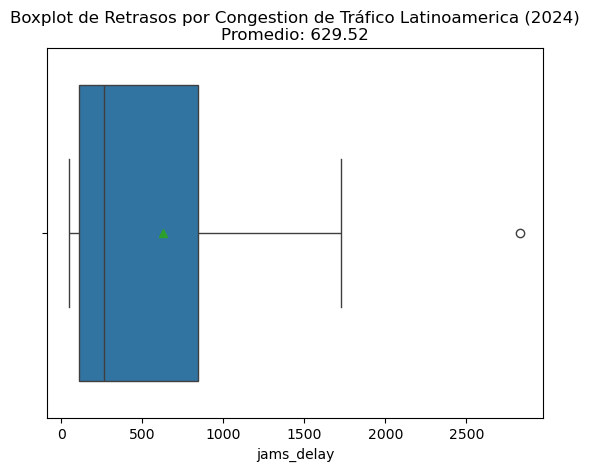

Q1=107.16593843601598
Q3=841.0790532733863
IQR=733.9131148373704


In [ ]:
# boxplot para observar el comportamiento de los minutos de congestion JamsDelay
sns.boxplot(data=merged, x='jams_delay',showmeans=True )
# promedio para mostrar en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de Retrasos por Congestion de Tráfico Latinoamerica (2024)\nPromedio: {mean_value:.2f}')
plt.show()

Q1 = merged['jams_delay'].quantile(0.25)
Q3 = merged['jams_delay'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1={Q1}')
print(f'Q3={Q3}')
print(f'IQR={IQR}')


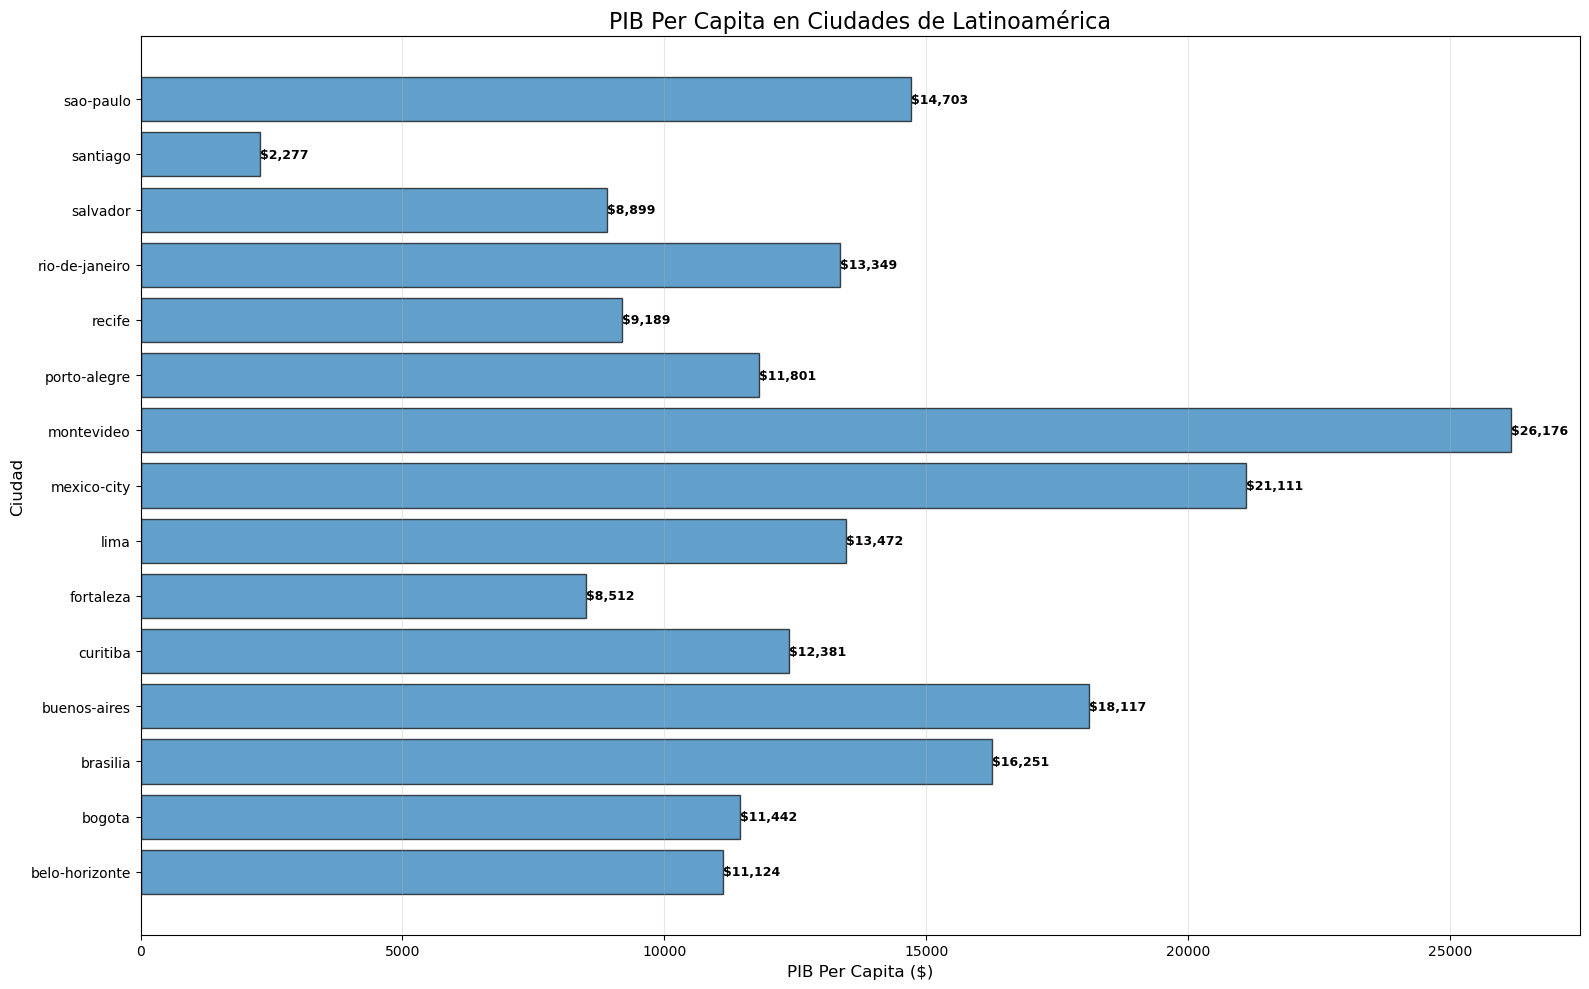

In [ ]:
# Barras horizontales para ver la distribución de la economía (city_gdp_capita)

# Preparar datos
fig, ax = plt.subplots(figsize=(16, 10))

# Barras horizontales
bars = ax.barh(merged['city'], merged['city_gdp_capita'],
               color='tab:blue', alpha=0.7, edgecolor='black')

# Añadir etiquetas de valores
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2,
            f'${width:,.0f}',
            ha='left', va='center', fontsize=9, fontweight='bold')

# Etiquetas
ax.set_xlabel('PIB Per Capita ($)', fontsize=12)
ax.set_ylabel('Ciudad', fontsize=12)
ax.set_title('PIB Per Capita en Ciudades de Latinoamérica', fontsize=16)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

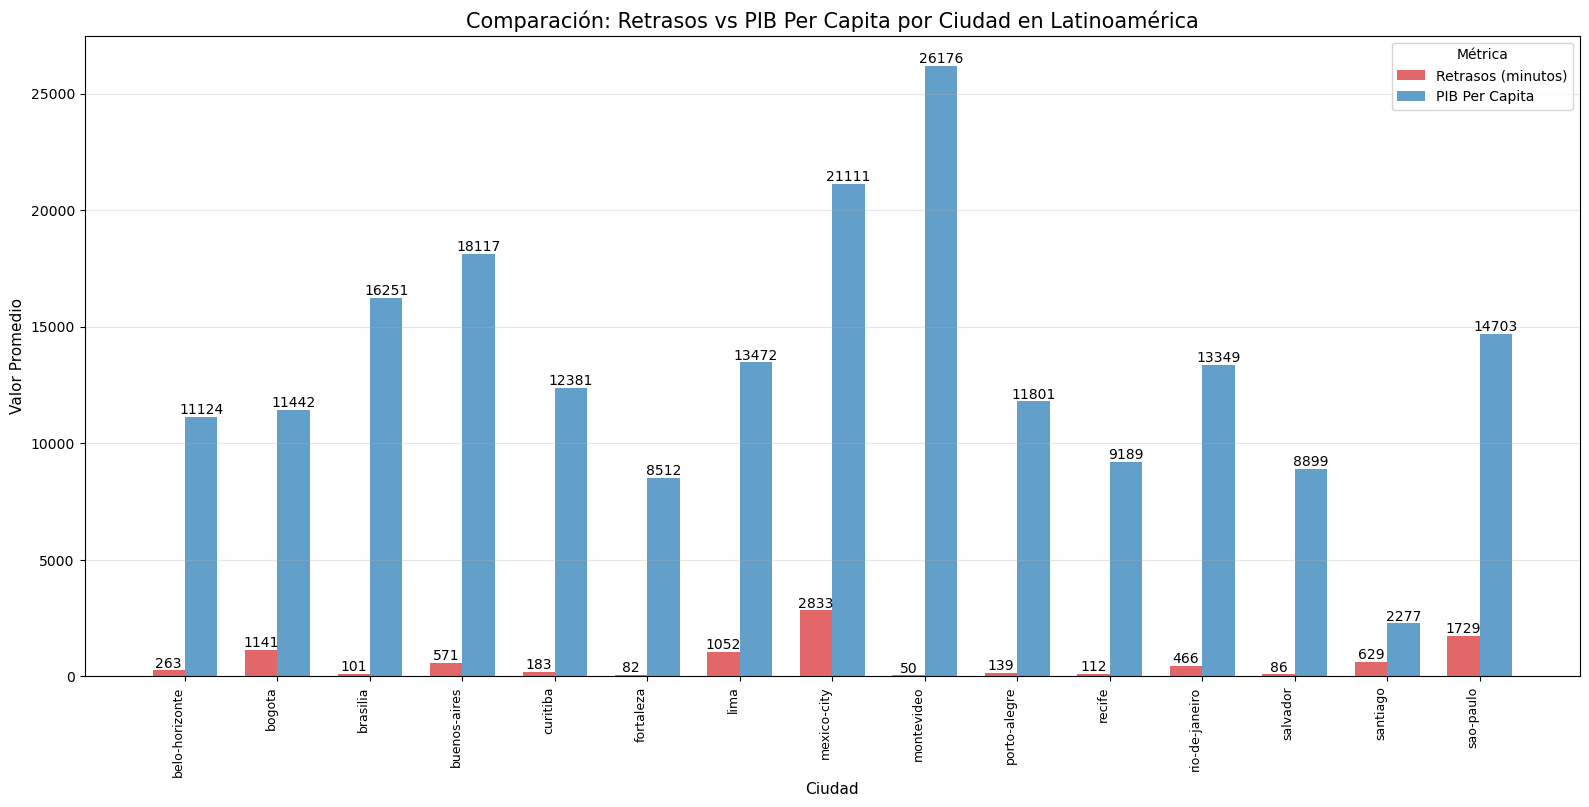

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
#merged.plot( ... , y=['jams_delay', 'city_gdp_capita'])
fig, ax = plt.subplots(figsize=(16, 8))

# Ancho de cada barra
bar_width = 0.35

# Posiciones de las barras
x = range(len(merged['city']))

# Barras agrupadas
ax.bar([i - bar_width/2 for i in x], merged['jams_delay'],
       width=bar_width, color='tab:red', alpha=0.7, label='Retrasos (minutos)')
ax.bar([i + bar_width/2 for i in x], merged['city_gdp_capita'],
       width=bar_width, color='tab:blue', alpha=0.7, label='PIB Per Capita')

# Etiquetas
ax.set_xlabel('Ciudad', fontsize=11)
ax.set_ylabel('Valor Promedio', fontsize=11)
ax.set_title('Comparación: Retrasos vs PIB Per Capita por Ciudad en Latinoamérica', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(merged['city'], rotation=45, ha='right', fontsize=9)
ax.legend(title='Métrica', fontsize=10)
ax.grid(axis='y', alpha=0.3)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.xticks(rotation=90)
plt.show()


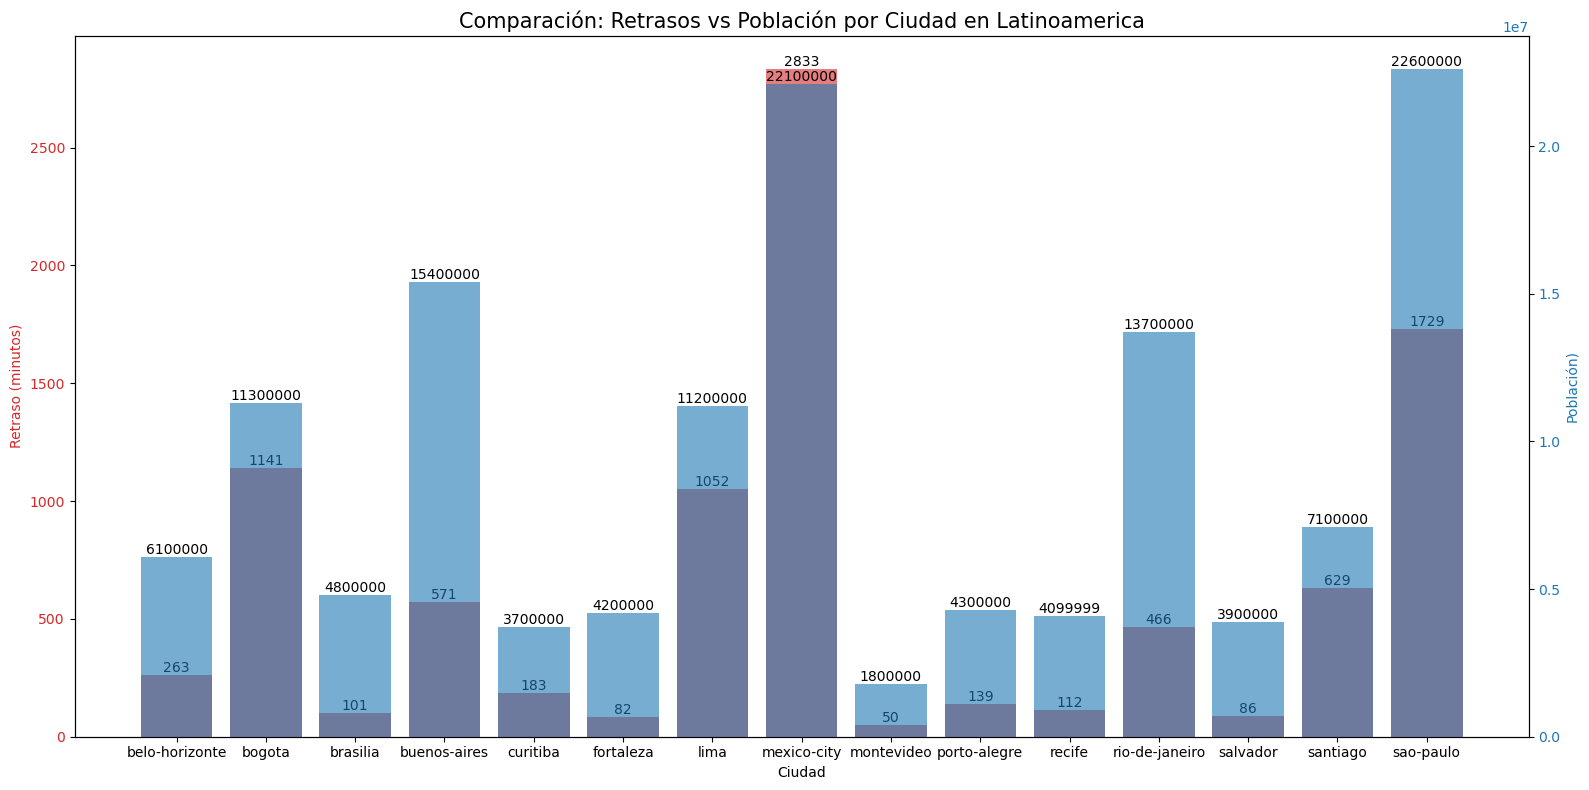

In [ ]:


# Ancho de cada barra
fig, ax1 = plt.subplots(figsize=(16, 8))
# Eje izquierdo - Jams Delay
color1 = 'tab:red'
ax1.set_xlabel('Ciudad')
ax1.set_ylabel('Retraso (minutos)', color=color1)
ax1.bar(merged['city'], merged['jams_delay'], color=color1, alpha=0.6, label='Jams Delay')
ax1.tick_params(axis='y', labelcolor=color1)

# Eje derecho - City GDP Per Capita
ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('Población)', color=color2)
ax2.bar(merged['city'], merged['population'], color=color2, alpha=0.6, label='City GDP Per Capita')
ax2.tick_params(axis='y', labelcolor=color2)

# Etiquetas y título
plt.title('Comparación: Retrasos vs Población por Ciudad en Latinoamerica', fontsize=15)
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.tight_layout()

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.show()

### 🧠 **Reflexión**

* Según los gráficos las ciudades con mayor PIB per capita no tienen mayor congestión, Montevideo tiene el mayor PIB de todas las ciudades, sin tener una congestión significativa.

* No se visualiza claramente una relación clara entre el PIB Per Capita y la congestión del tráfico, Sin embargo, si se ve que un PIB alto influye en la congestión de la ciudad.


---

## 🧩Paso 7: Exportación y documentación de resultados

En esta etapa final se guarda el dataset limpio y crea un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

In [ ]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


---

# 🧾 Resumen ejecutivo

**Contexto & objetivo:**  
- Este análisis evalúa la relación entre la congestión urbana y el PIB per cápita en 15 ciudades latinoamericanas durante 2024.

- Los resultados muestran que no existe una relación directamente proporcional entre mayor ingreso y mayor congestión. Esto sugiere que la movilidad urbana depende no solo del nivel económico, sino también de factores estructurales como planificación, infraestructura y gestión del transporte.

- Las variables analizadas permiten dimensionar el impacto económico del tráfico y apoyar decisiones estratégicas en planificación urbana y logística.

**Cobertura de datos:**  
- El análisis abarca el año 2024 e incluye un total de 15 ciudades distribuidas en 7 países de latinoamérica.

**Metodología (alto nivel):**  
Se realizó la limpieza y validación de los datos, corrigiendo formatos numéricos y de fecha, y verificando la ausencia de valores negativos o inconsistentes en el retraso total. Posteriormente, se filtró la información por año (2024) y países de Latinoamérica.

Se calcularon promedios de tráfico por ciudad, se ordenaron los datos según el retraso total y se definieron las variables clave. Las bases de datos fueron integradas mediante un outer join para conservar todos los registros relevantes.

Finalmente, se elaboraron gráficos (boxplot y gráficos de barras horizontales y comparativos) para facilitar el análisis y la visualización de los resultados.

**Hallazgos iniciales:**  
- La distribución del retraso total presenta asimetría positiva, influenciada por uno o pocos valores atípicos altos, mientras que la mayoría de las ciudades se concentran en niveles de congestión entre 107 y 834.
  
- No se observa una relación directamente proporcional entre el PIB per cápita y el retraso total por congestión. Por ejemplo, Montevideo registra el mayor PIB per cápita del grupo (26176) sin presentar niveles elevados de congestión (50), lo que sugiere que el desarrollo económico no es, por sí solo, un determinante de la congestión urbana, para decir que el PIB per capita es directamente proporcional a los niveles elevados de congestión. De igual manera, tampoco de observa un comportamiento inversamente proporcional en donde bajos PIB per capital como en la ciudad de Santiago (2277) reflejen altos niveles de congestion (629).

- Se identifica una correlación positiva entre población y retraso total: a mayor población, mayor volumen agregado de congestión. No obstante, esta relación debe interpretarse con cautela, ya que el retraso total es una variable acumulativa que tiende a crecer con el tamaño del sistema urbano. Por ejemplo en la ciudad de Mexico con 22 millones de habitantes, tiene un retraso alto de 2833, mientras que cluidades con poblaciones bajas como montevideo 1 millon 800, cuentas con niveles de congestion baja de 50.

**Recomendaciones**  

- Dado que el retraso total es una variable acumulativa, se recomienda calcular retraso per cápita, estimar retraso por kilómetro de vía monitoreada o  analizar retraso promedio por viaje para normalizar la variable de congestión.

- Un mayor PIB per cápita no implica mayor congestión (como el caso de Montevideo), Se sugiere para futuros análisis tener en cuenta variables como la inversión en transporte público,  densidad urbana, tasa de motorización y las políticas de gestión de tráfico.

- Dentro de las ciudades que poseen altos niveles de congestión vehicular y bajos indicadores de productividad económica están Bogotá, en Colombia, y Sao Paulo, en Brasil, lo que sugiere que estas ciudades pueden prioritarias para la inversión en infraestructura de transporte.
